In [1]:
using DifferentialEquations
using JumpProcesses
using Plots
# using PlotlyJS
using Statistics
using Distributions
using Random
using JLD2

using Optimization
using OptimizationOptimJL
# using BlackBoxOptim

using CSV
using DataFrames
using DelimitedFiles

# include own module with functionalities, ATTENTION, this will include StatsPlots
include("functionalities.jl")


# set seed for reproducibility
Random.seed!(123);

# Gyllenberg-Webb Model
Having the following three-compartment tumour growth model consisting of proliferative, quiescent and death cells.
$$
\begin{array}{c}
\frac{dP}{dt}=(b-r_0(N))P+r_i(N)Q,\\
\frac{dQ}{dt}=r_0(N)P-(r_i(N)+\mu)Q,\\
\frac{dR}{dt}=\mu Q(t)-d R(t)\\
M(t)=P(t)+Q(t)+R(t)
\end{array}
$$
with cells transition function
$$
r_i(M)=\frac{r}{M+m},\quad r_0(M)=\frac{kM}{aM+1}
$$
Fixed parameter values are $k=2, a=1, m=2, d=0.01, r=1$ and the parameter of interest sre $b, \mu$.

We are interested in the tumour size that contirbutes to metastasisation $S(t)=P(t)+Q(t)$.

In [2]:
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D

@parameters begin
    r = 1
    k = 2
    a = 1
    b = 1
    m = 2
    μ = 0.5
    d = 0.01
end
@variables begin
    P(t) = 0
    Q(t) = 0
    De(t) = 0
end

total_N(P,Q,De) = P+Q
r0(P,Q,De) = k*total_N(P,Q,De)/(a*total_N(P,Q,De)+1)
ri(P,Q,De) = r/(total_N(P,Q,De)+m)


# r0(P,Q) = k*total_N(P,Q)^2
# ri(P,Q) = r

eqs = [
    D(P) ~ (b-r0(P,Q,De))*P+ri(P,Q,De)*Q
    D(Q) ~ r0(P,Q,De)*P-(ri(P,Q,De)+μ)*Q
    D(De) ~ μ*Q-d*De
    ]

@named sys = ODESystem(eqs, t, [P,Q, De], [r,k,a,b,m,μ,d])
sys = structural_simplify(sys)

Model sys:
Equations (3):
  3 standard: see equations(sys)
Unknowns (3): see unknowns(sys)
  P(t) [defaults to 0]
  Q(t) [defaults to 0]
  De(t) [defaults to 0]
Parameters (7): see parameters(sys)
  a [defaults to 1]
  μ [defaults to 0.5]
  r [defaults to 1]
  d [defaults to 0.01]
  ⋮

In [3]:
tspan = (0.0, 30.0)

parammap = [sys.μ => 0.05, sys.b => 1.0, sys.a => 0.03, sys.k => 0.05, sys.r => 0.1, sys.m => 2, sys.d => 0.01]
initial_conditions = [sys.P => 1.0, sys.Q => 0.0, sys.De => 0.0]
odeprob = ODEProblem(sys, parammap, tspan, initial_conditions)

odesol = solve(odeprob, Tsit5(), saveat=0.1);

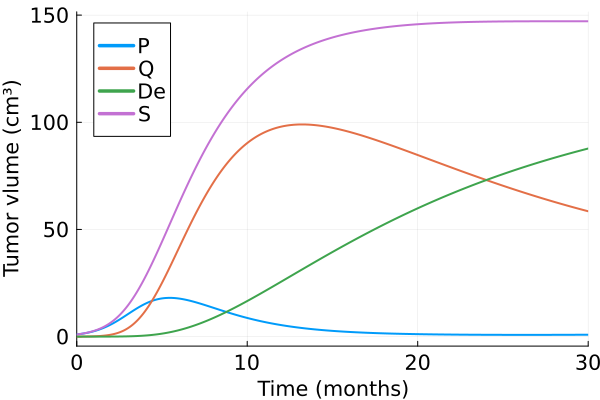

In [11]:
plt = plot(odesol, vars=[sys.P, sys.Q, sys.De], lw=2)
plot!(plt, odesol.t, odesol[:P]+odesol[:Q]+odesol[:De], label="M", lw=2)
plot!(tickfontsize=14, legendfontsize=14, guidefontsize=14, titlefontsize=14, legend=:topleft)
plot!(plt, xlabel="Time (months)", ylabel="Tumor vlume (cm³)")

In [12]:
savefig(plt, "figures/GyllenbergWebb_growth.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/GyllenbergWebb_growth.pdf"

### Data generation
Lets try to use this growth in our simulation algorithm.

In [14]:
include("general_MNR_simulation_algorithm.jl")


function TotalTumorSize(P0, p; endtime=30.0)
    parammap = [sys.μ => p.μ, sys.b => p.b, sys.a => 0.03, sys.k => 0.05, sys.r => 0.1, sys.m => 2, sys.d => 0.01]
    initial_conditions = [sys.P => P0, sys.Q => 0.0, sys.De => 0.0]
    prob = ODEProblem(sys, parammap, (0.0, endtime), initial_conditions)
    sol = solve(prob, Tsit5(), reltol=1e-8, abstol=1e-8)
    return sol
end

# set parameters
b = 1
μ = 0.05
p = (b = b, μ = μ, m_basal = 0.04, m_size = 0.04, d_size = 0.01, d_metastasis = 0.01)
θ = [b, μ, p.m_basal, p.m_size, p.d_size, p.d_metastasis]
P0 = 1.0
endtime = 30;

In [ ]:
npat = 500
patient_df = simulate_many_MNR(p, TotalTumorSize, npat=500)
# # save the data
# save("data/simplified_model/gyllenberg_data_$(npat)_patients_$(θ).jld2", "gyllenberg_data", patient_df)


In [16]:
# load the data
npat = 500
gyllenberg_patient_df = load("data/simplified_model/gyllenberg_data_$(npat)_patients_$(θ).jld2")["gyllenberg_data"]
data_summary(gyllenberg_patient_df)

Dict{String, Real} with 10 entries:
  "Mean survival time:"          => 10.7647
  "Low Quantile survival time:"  => 6.282
  "Mean metastasis at day 10:"   => 2.99602
  "Mean metastasis at death:"    => 3.65927
  "Mean tumor size at day 10:"   => 115.515
  "High Quantile survival time:" => 14.2895
  "Maximal metastasis number:"   => 18
  "Mean metastasis at day 20:"   => 7.4878
  "Patients died:"               => 496
  "Maximum metastasis increase:" => 4

### Inference
We can only do Numeric-Likelihoods but for those inference is not a problem. We also do it in a hierarchical fashion in this notebook.

In [2]:
include("GyllenbergWebbLikelihoods.jl")
import .GyllenbergWebbLikelihoods as GWL

In [ ]:
using LatinHypercubeSampling

log_lb_x0 = [-0.5, -4, -6, -6, -8, -8]
log_ub_x0 = [1, 0, -1, -1, -2, -2]

n_starts = 100 

plan,_ = LHCoptim(n_starts, length(log_lb_x0), 1000)
scaled_plan = scaleLHC(plan, [(log_lb_x0[i], log_ub_x0[i]) for i in eachindex(log_lb_x0)]);

x0_vectors = [scaled_plan[i, :] for i in 1:size(scaled_plan, 1)];

# save startpoints
# save("data/startpoints_gyllenberg_likelihoods_$(n_starts)_starts_$(npat)_patients_$(θ).jld2", "startpoints", x0_vectors)
npat = 500
x0_vectors = load("data/startpoints_gyllenberg_likelihoods_$(n_starts)_starts_$(npat)_patients_$(θ).jld2")["startpoints"];

x0 = x0_vectors[1]

6-element Vector{Float64}:
  0.6515151515151516
 -0.3232323232323231
 -5.696969696969697
 -2.9696969696969697
 -4.303030303030303
 -7.2727272727272725

In [40]:
betaOptim(x, p) = GWL.TumorNegLogLikelihood(x[1], x[2], gyllenberg_patient_df, S0=1.0)
betaOptimFunc = OptimizationFunction(betaOptim)
betaOptimProblem = OptimizationProblem(betaOptimFunc, exp.(x0)[1:2], lb=zeros(2).+1e-4, ub=ones(2) .+ 2)
bEst = solve(betaOptimProblem, SAMIN(), maxiters=10^5, maxtime=300.0)
println("b:", bEst[1], "μ:", bEst[2], "\n")

SAMIN results
==> Normal convergence <==
total number of objective function evaluations: 20701

     Obj. value:  13593.3272772489

       parameter      search width
         0.99719           0.00000 
         0.05040           0.00000 

b:0.9971899697807474μ:0.050401710768332365



In [9]:
metOptim(x, p) = GWL.MetastasisNegLogLikelihood([1.0, 0.05, x[1], x[2]], gyllenberg_patient_df, S0=1.0)
metOptimFunc = OptimizationFunction(metOptim, Optimization.AutoForwardDiff())
metOptimProblem = OptimizationProblem(metOptimFunc, exp.(x0[3:4]), lb=zeros(2).+1e-8, ub=ones(2))
metEst = solve(metOptimProblem, SAMIN(), maxiters=10^5, maxtime=300.0)
println("Metastasis:", metEst, "\n")

SAMIN results
NO CONVERGENCE: MAXEVALS exceeded

     Obj. value:        3969.38970

       parameter      search width
         0.06666           0.05273 
         0.03815           0.00742 
Metastasis:retcode: Failure
u: [0.06665721581065581, 0.03815245627433463]
Final objective value:     3969.3897021616363




In [ ]:
deathOptim(x, p) = GWL.DeathNegLogLikelihood([1.0, 0.05, 0.04, 0.04, x[1], x[2]], gyllenberg_patient_df, S0=1.0)
deathOptimFunc = OptimizationFunction(deathOptim)
deathOptimProblem = OptimizationProblem(deathOptimFunc, exp.(x0[4:5]), lb=zeros(2).+1e-4, ub=ones(2))
deathEst = solve(deathOptimProblem, SAMIN(), maxiters=10^6, maxtime=300.0)
println("Death Estimation:", deathEst, "\n")

Load the optimization results of 100 starts.

In [26]:
# load optimization result
nstarts = 100
optimizer = "SAMIN"
Llh_type ="Numeric"
hier_result_path = joinpath(pwd(),"output/results/gyllenberg_hierarchical_optimization_$(nstarts)_starts_$(optimizer)_$(Llh_type).jld2")
hier_results = load(hier_result_path)["results"]
hier_par_names = hier_results["par_names"]
hier_results = hier_results["optimization_results"]
hier_nllhs_list = [hier_results[i]["nllh"] for i in 1:nstarts]
hier_par_list = [hier_results[i]["parameter"] for i in 1:nstarts];

hier_example = hier_results[1]
ex_par = exp.(hier_example["parameter"])

6-element Vector{Float64}:
 0.9971899682778333
 0.05040171239650601
 0.06635886655907405
 0.03828301154986044
 0.009489109975496911
 0.010743135135550242

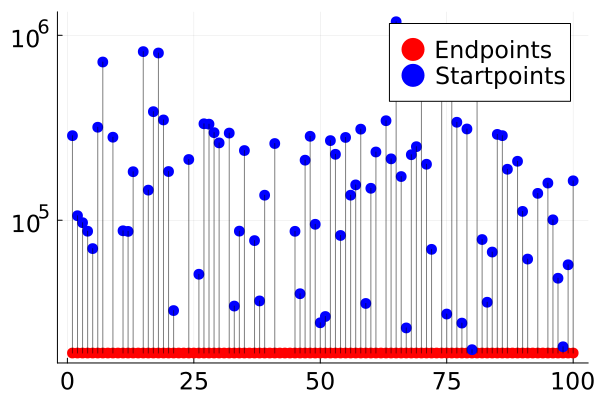

In [74]:
cg = cgrad(:hsv, range(0, 1, length=nstarts))

perm = sortperm(hier_nllhs_list)
hier_nllhs_list .= hier_nllhs_list[perm]
hier_par_list .= hier_par_list[perm]

# set grouping by fval for color
rel_threshold = 1
k = 1
z = zeros(nstarts)
for i in 1:nstarts
    if i == 1
        z[i] = k
    else
        if hier_nllhs_list[i] - hier_nllhs_list[i-1] <= rel_threshold
            z[i] = k
        else
            k = k + 1
            z[i] = k
        end
    end
end

# cg = cgrad(:hsv, range(0, 1, length=Int(z[end])))

gr(markerstrokewidth=0,markersize=6)
plt = Plots.plot(hier_nllhs_list, linecolor=:black,label=false,  yscale=:log10, legend=:best)
Plots.scatter!(plt, 1:1:100, hier_nllhs_list,  color=cg[Int.(z)], markershape=:circle, label="Endpoints")
scatter!(plt, 1:1:100, x0_nllhs, color=:blue, label="Startpoints")
for i in 1:nstarts
    plot!(plt, [i, i], [x0_nllhs[i], hier_nllhs_list[i]], color=:black, label=false, alpha=0.5)
end

plot!(plt, legendfontsize=16, tickfontsize=16, guidefontsize=16)
display(plt)


In [75]:
savefig(joinpath(pwd(), "figures/double_waterfall_plot_gyllenberg_hierarchical_optimisation_$(optimizer)_$(nstarts)_starts_$(Llh_type).pdf"))

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/double_waterfall_plot_gyllenberg_hierarchical_optimisation_SAMIN_100_starts_Numeric.pdf"

### Sampling


In [23]:
using MCMCChains
using StatsPlots
include("functionalities.jl")
using HDF5

In [52]:
# load result hdf5 file
n_iter = 50000
n_chains = 4
result_path = joinpath(pwd(), "output/simplified_model/sampling_gyllenberg_$(n_chains)chs_$(n_iter)it_$(θ).h5")
chain_dict = h5open(result_path, "r") do file
    read(file,)
end
chain = dict_to_chain(chain_dict, ["b", "mu", "m_basal", "m_size", "d_size", "d_metastasis"], n_chains, n_iter)
burn_in = burn_in_from_geweke(chain)
if burn_in >= length(chain)
    burn_in = Int(floor(length(chain)/2))
    
end
chain = chain[burn_in:end]

Chains MCMC chain (10002×6×4 Array{Float64, 3}):

Iterations        = 40000:1:50001
Number of chains  = 4
Samples per chain = 10002
parameters        = b, mu, m_basal, m_size, d_size, d_metastasis

Summary Statistics
    parameters      mean       std      mcse    ess_bulk    ess_tail      rhat ⋯
        Symbol   Float64   Float64   Float64     Float64     Float64   Float64 ⋯

             b    0.9973    0.0025    0.0001   2241.2752   3788.6568    1.0048 ⋯
            mu    0.0502    0.0030    0.0001   2348.8678   3534.4547    1.0026 ⋯
       m_basal    0.0670    0.0144    0.0003   2228.6413   3749.4888    1.0034 ⋯
        m_size    0.0383    0.0019    0.0000   2282.2986   2787.4885    1.0023 ⋯
        d_size    0.0095    0.0008    0.0000   2419.8625   3428.8238    1.0025 ⋯
  d_metastasis    0.0107    0.0023    0.0000   2413.6299   3849.9075    1.0032 ⋯
                                                                1 column omitted

Quantiles
    parameters      2.5%     25.0%     50.

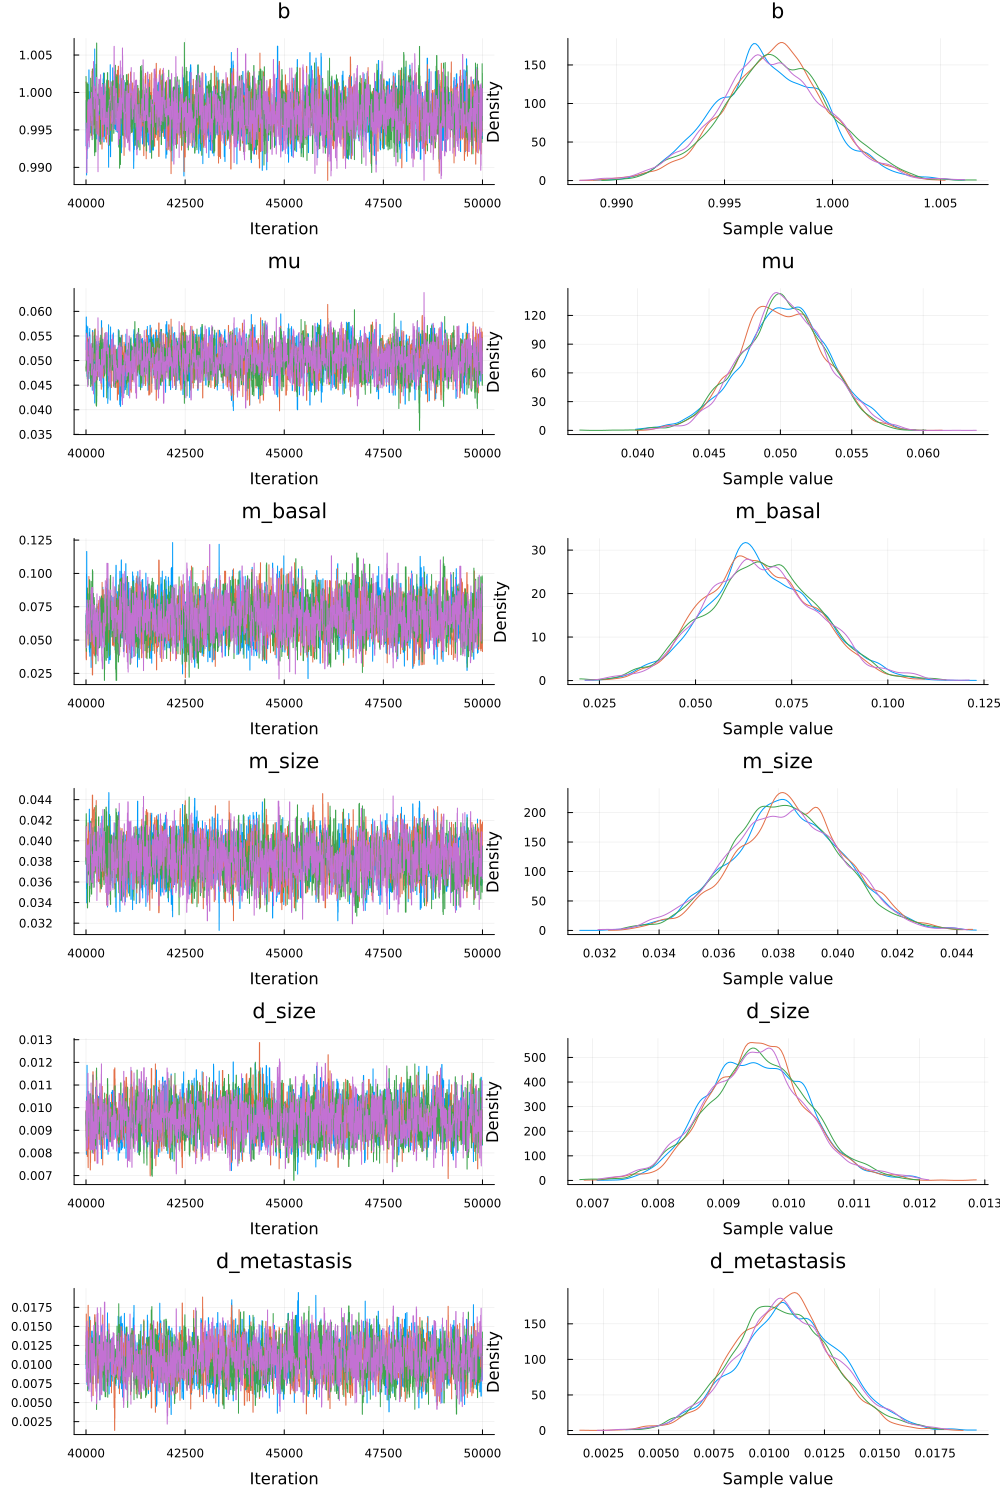

In [53]:
plot(chain)

In [57]:
# taken from the hierarchical results loaded above
example_par = exp.(hier_example["parameter"]);
par_names = ["b", "mu", "m_basal", "m_size", "d_size", "d_metastasis"];

In [60]:
par_quantiles = quantile(chain; q=[0.01, 0.025, 0.05, 0.1, 0.5, 0.9, 0.95, 0.975, 0.99])

Quantiles
    parameters      1.0%      2.5%      5.0%     10.0%     50.0%     90.0%     ⋯
        Symbol   Float64   Float64   Float64   Float64   Float64   Float64   F ⋯

             b    0.9914    0.9923    0.9931    0.9941    0.9972    1.0005     ⋯
            mu    0.0430    0.0443    0.0452    0.0463    0.0502    0.0540     ⋯
       m_basal    0.0350    0.0397    0.0442    0.0487    0.0664    0.0857     ⋯
        m_size    0.0339    0.0346    0.0352    0.0359    0.0383    0.0407     ⋯
        d_size    0.0078    0.0081    0.0083    0.0085    0.0095    0.0105     ⋯
  d_metastasis    0.0055    0.0063    0.0070    0.0078    0.0107    0.0137     ⋯
                                                               3 columns omitted


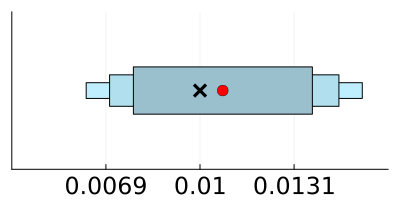

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/gyllenberg_d_metastasis_estimate_cis.pdf"

In [ ]:
par_id = 6
true_par = [1.0, 0.05, 0.04, 0.04, 0.01, 0.01]

plt = bar([0.5],
    [par_quantiles.nt[9][par_id]], 
    fillto=[par_quantiles.nt[3][par_id]], 
    xlimits=(par_quantiles.nt[2][par_id], par_quantiles.nt[10][par_id]),
    orientation=:h, 
    bar_width=0.1,
    color=:lightblue1,
    alpha=1.0, 
    label="95%CI")
bar!(plt, [0.5],
    [par_quantiles.nt[8][par_id]], 
    fillto=[par_quantiles.nt[4][par_id]], 
    xlimits=(par_quantiles.nt[2][par_id], par_quantiles.nt[10][par_id]),
    orientation=:h, 
    bar_width=0.2,
    color=:lightblue2,
    alpha=1.0, 
    label="90%CI")
bar!(plt, [0.5],
    [par_quantiles.nt[7][par_id]], 
    fillto=[par_quantiles.nt[5][par_id]], 
    xlimits=(par_quantiles.nt[2][par_id], par_quantiles.nt[10][par_id]),
    ylimits=(0.0, 1.0),
    orientation=:h, 
    bar_width=0.3,
    alpha=1.0, 
    color=:lightblue3,
    yticks=false,
    label="80%CI")
plot!([example_par[par_id]],[0.5], seriestype=:scatter, label="MLE", color=:red, markersize=6)
plot!([true_par[par_id]],[0.5], seriestype=:scatter, marker=:xcross, markerstrokewidth=8, label="True", color=:black, markersize=6)
x = true_par[par_id]
x_lower_limit = max(0, x-max(x-par_quantiles.nt[2][par_id], par_quantiles.nt[10][par_id]-x))
x_upper_limit = x+max(x-par_quantiles.nt[2][par_id], par_quantiles.nt[10][par_id]-x)
plot!(xlimits=(x_lower_limit, x_upper_limit))
x_ticks = LinRange(x_lower_limit, x_upper_limit, 5)[2:end-1]
plot!(xticks = (x_ticks, round.(x_ticks, digits=4)))
plot!(size=(400, 200), formatter=:plain, legend=false, tickfontsize=16, legendfontsize=16, guidefontsize=16)
display(plt)
# savefig("figures/gyllenberg_$(par_names[par_id])_estimate_cis.pdf")
